# Credit Card Fraud Detection - Exploratory Data Analysis

This notebook performs comprehensive exploratory data analysis on credit card transaction data to identify patterns and features indicative of fraudulent transactions. The analysis includes:
- Data loading and basic statistics
- Distribution analysis by fraud status
- Temporal pattern analysis
- Merchant risk assessment
- Key behavioral indicators (CVV mismatches, card presence, account age, etc.)
- Feature importance evaluation
- Feature engineering for machine learning models

In [1]:
# Import required libraries for data analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import json

# Configure pandas display to show more columns
pd.set_option("display.max_columns", 30)

## 1. Data Loading & Basic Setup

Load transaction data from JSON format and perform initial data exploration.

In [2]:
# Load transaction data from JSON file (each line is a JSON object)
records = []
with open("../../data/transactions.txt", "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

# Convert to DataFrame
df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (786363, 29)


,accountNumber,customerId,creditLimit,availableMoney,transactionDateTime,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,merchantCategoryCode,currentExpDate,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,echoBuffer,currentBalance,merchantCity,merchantState,merchantZip,cardPresent,posOnPremises,recurringAuthInd,expirationDateKeyInMatch,isFraud
0,737265056,737265056,5000.0,5000.0,2016-08-13T14:27:32,98.55,Uber,US,US,02,01,rideshare,06/2023,2015-03-14,2015-03-14,414,414,1803,PURCHASE,,0.0,,,,False,,,False,False
1,737265056,737265056,5000.0,5000.0,2016-10-11T05:05:54,74.51,AMC #191138,US,US,09,01,entertainment,02/2024,2015-03-14,2015-03-14,486,486,767,PURCHASE,,0.0,,,,True,,,False,False
2,737265056,737265056,5000.0,5000.0,2016-11-08T09:18:39,7.47,Play Store,US,US,09,01,mobileapps,08/2025,2015-03-14,2015-03-14,486,486,767,PURCHASE,,0.0,,,,False,,,False,False
3,737265056,737265056,5000.0,5000.0,2016-12-10T02:14:50,7.47,Play Store,US,US,09,01,mobileapps,08/2025,2015-03-14,2015-03-14,486,486,767,PURCHASE,,0.0,,,,False,,,False,False
4,830329091,830329091,5000.0,5000.0,2016-03-24T21:04:46,71.18,Tim Hortons #947751,US,US,02,01,fastfood,10/2029,2015-08-06,2015-08-06,885,885,3143,PURCHASE,,0.0,,,,True,,,False,False


In [3]:
# Check date range of the dataset
df.transactionDateTime.min(), df.transactionDateTime.max()

('2016-01-01T00:01:02', '2016-12-30T23:59:45')

## 2. Initial Data Exploration

Check data ranges, unique entities, and basic statistics.

In [4]:
# Count unique accounts and customers
account_count = df.accountNumber.nunique()
customer_count = df.customerId.nunique()
total_transactions = len(df)
print(f"Unique Accounts: {account_count}, Unique Customers: {customer_count}, Total Transactions: {total_transactions}")
account_count, customer_count, total_transactions

Unique Accounts: 5000, Unique Customers: 5000, Total Transactions: 786363


(5000, 5000, 786363)

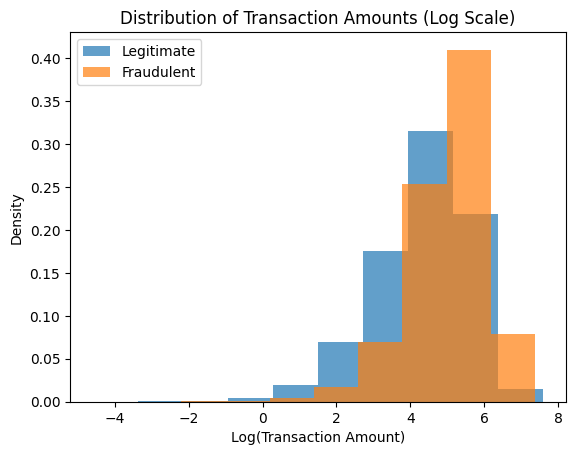

In [5]:
# Plot distribution of transaction amounts (log scale) for fraudulent and legitimate transactions
plt.hist(np.log(df.query("isFraud == False and transactionAmount > 0")['transactionAmount']), density=True, label='Legitimate', alpha=0.7)
plt.hist(np.log(df.query("isFraud == True and transactionAmount > 0")['transactionAmount']), density=True, label='Fraudulent', alpha=0.7)
plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Density")
plt.title("Distribution of Transaction Amounts (Log Scale)")
plt.legend()
plt.show()

## 3. Distribution Analysis by Fraud Status

Visualize how transaction characteristics differ between fraudulent and legitimate transactions.

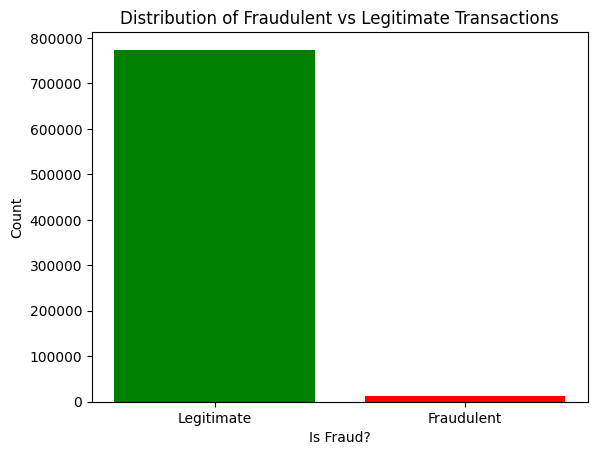

In [6]:
# Bar plot showing the count of fraudulent vs legitimate transactions
fraud_counts = df['isFraud'].value_counts()
plt.bar(fraud_counts.index, fraud_counts.values, color=("green", "red"))
plt.xlabel("Is Fraud?")
plt.ylabel("Count")
plt.title("Distribution of Fraudulent vs Legitimate Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])
plt.show()

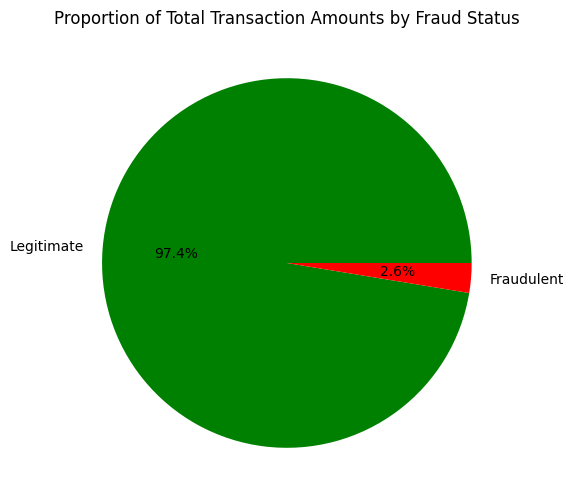

In [7]:
## fraud amount pie chart
plt.figure(figsize=(10, 6))
fraud_amounts = df.groupby('isFraud')['transactionAmount'].sum()
plt.pie(fraud_amounts, labels=['Legitimate', 'Fraudulent'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Proportion of Total Transaction Amounts by Fraud Status")
plt.show()

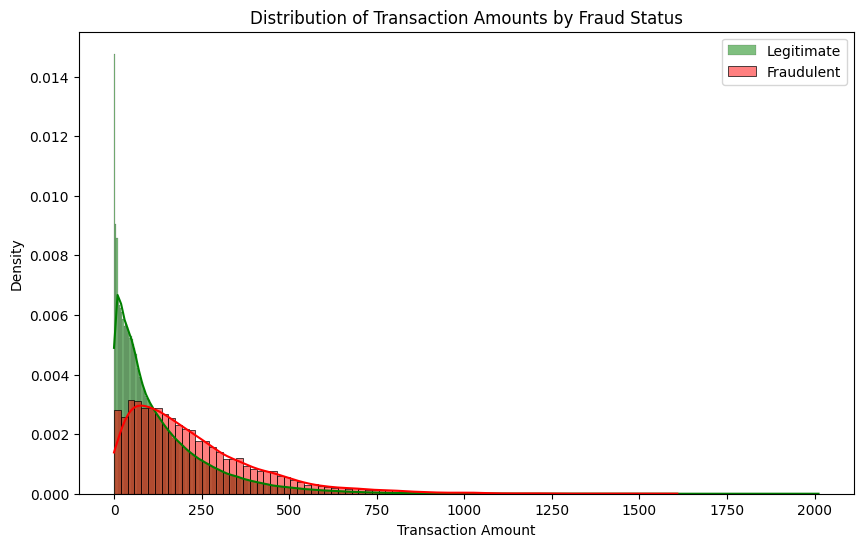

In [8]:
# Distribution of transaction amounts for fraudulent vs legitimate transactions
plt.figure(figsize=(10, 6))
sns.histplot(df.query("isFraud == False")['transactionAmount'], color='green', label='Legitimate', kde=True, stat="density")
sns.histplot(df.query("isFraud == True")['transactionAmount'], color='red', label='Fraudulent', kde=True, stat="density")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.title("Distribution of Transaction Amounts by Fraud Status")
plt.legend()
plt.show()

In [9]:
# Helper function to visualize transaction patterns by time attribute
# Creates two subplots: transaction count and average amount, both split by fraud status
def plot_transaction_time_distribution(df, dt_attr, xlabel, title):
    """
    Plot transaction distribution by time attribute and fraud status.
    
    Args:
        df: DataFrame with transaction data
        dt_attr: datetime attribute (e.g., 'hour', 'dayofweek', 'month')
        xlabel: Label for x-axis
        title: Plot title
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    df = df.copy()
    # Extract time attribute from transactionDateTime
    df["transactionTimeValue"] = getattr(pd.to_datetime(df["transactionDateTime"]).dt, dt_attr)
    
    # Left plot: Transaction count by fraud status
    df.pivot_table(index="transactionTimeValue", columns="isFraud", values="accountNumber", aggfunc="count").plot(kind="bar", stacked=True, color=["lightgreen", "red"], ax=axes[0])
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Number of Transactions")
    axes[0].set_title(title)
    axes[0].legend(title="Is Fraud?", labels=["Legitimate", "Fraudulent"])
    axes[0].tick_params(axis='x', rotation=0)

    # Right plot: Average transaction amount by fraud status
    df.pivot_table(index="transactionTimeValue", columns="isFraud", values="transactionAmount", aggfunc="mean").plot(kind="bar", stacked=True, color=["lightgreen", "red"], ax=axes[1])
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Average Transaction Amount")
    axes[1].set_title(f"Average Transaction Amount by {xlabel} and Fraud Status")
    axes[1].legend(title="Is Fraud?", labels=["Legitimate", "Fraudulent"])
    axes[1].tick_params(axis='x', rotation=0)
    plt.show()

## 4. Temporal Pattern Analysis

Analyze fraud patterns across different time dimensions (hour, day of week, month, year).

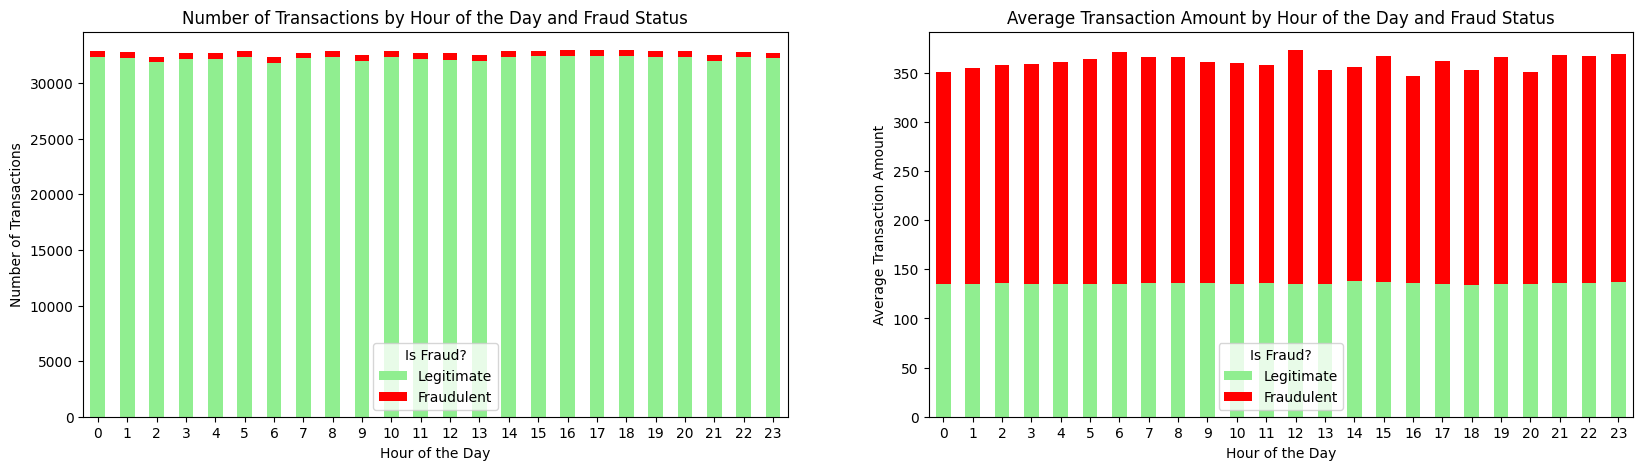

In [10]:
# Analyze fraud patterns by hour of the day
# Identify if certain times of day are more prone to fraud
plot_transaction_time_distribution(
    df,
    "hour",
    "Hour of the Day",
    "Number of Transactions by Hour of the Day and Fraud Status"
)

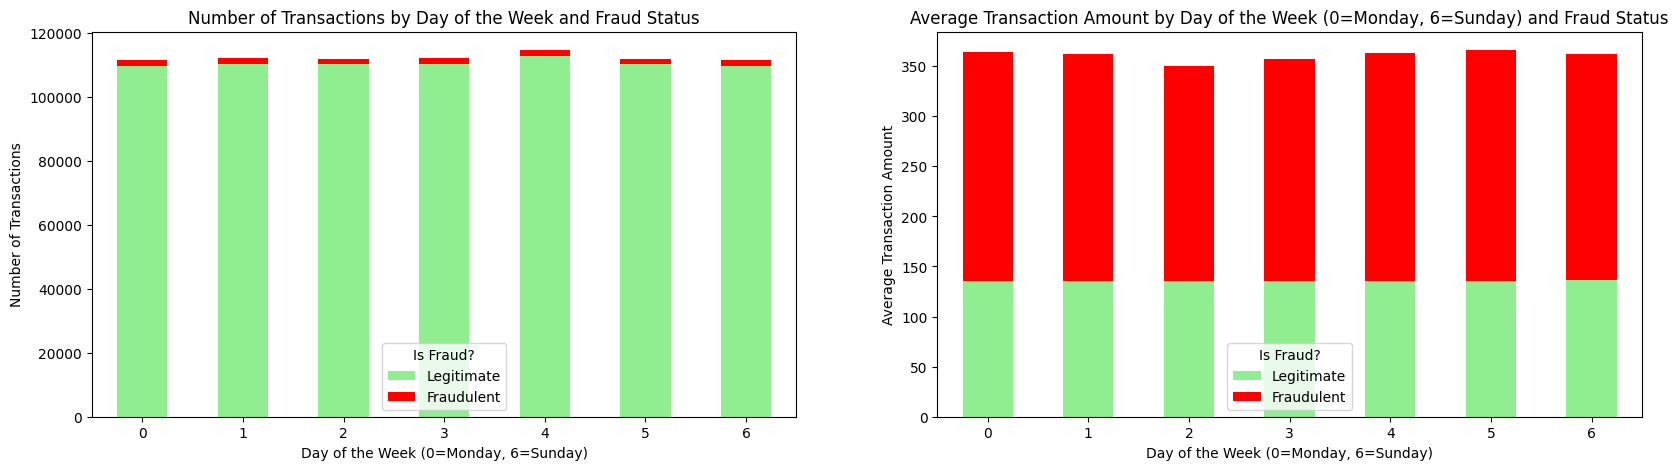

In [11]:
# Analyze fraud patterns by day of the week (0=Monday, 6=Sunday)
# Check if certain days have higher fraud rates
plot_transaction_time_distribution(
    df,
    "dayofweek",
    "Day of the Week (0=Monday, 6=Sunday)",
    "Number of Transactions by Day of the Week and Fraud Status"
)

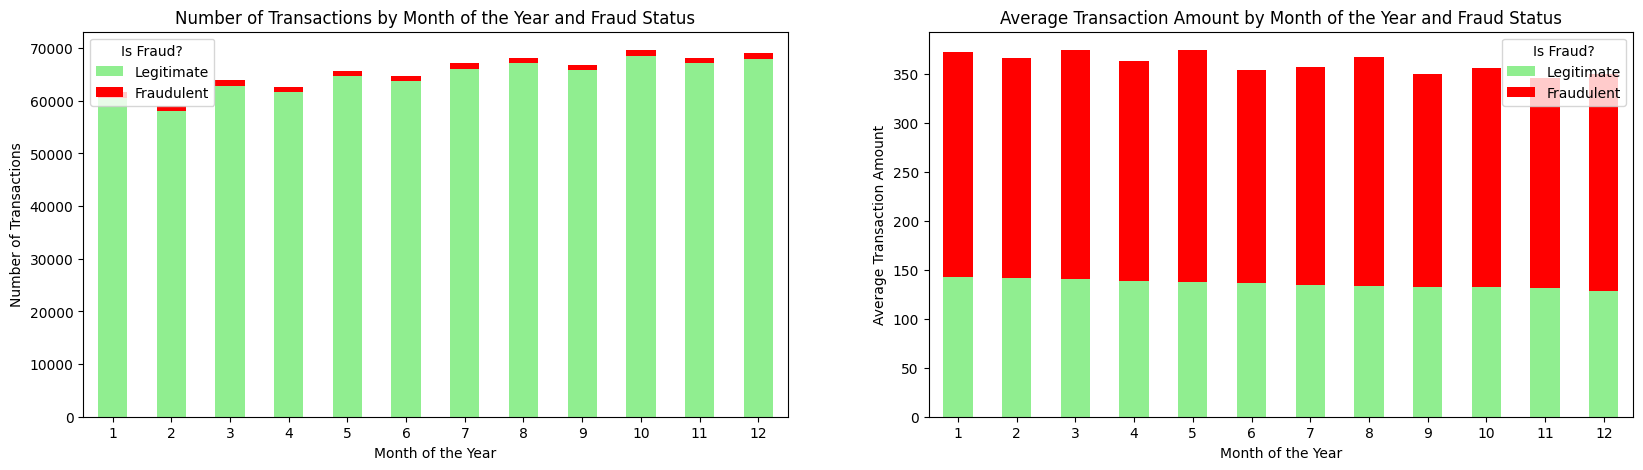

In [12]:
# Analyze fraud patterns by month of the year
# Identify seasonal fraud trends
plot_transaction_time_distribution(
    df,
    "month",
    "Month of the Year",
    "Number of Transactions by Month of the Year and Fraud Status"
)

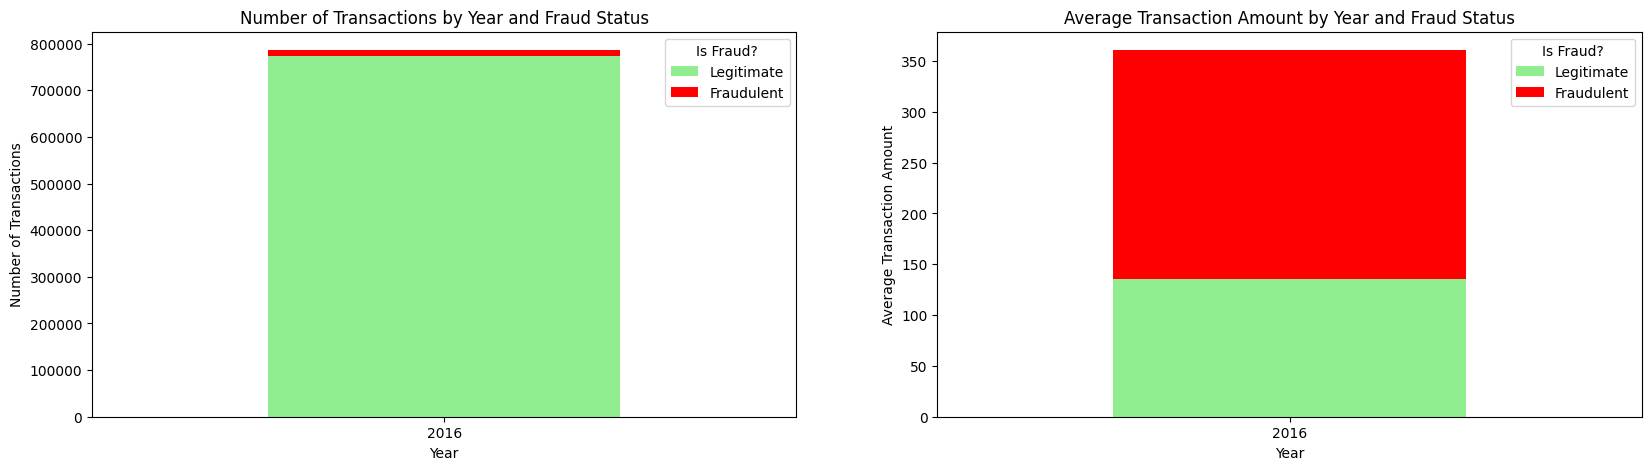

In [13]:
# Analyze fraud patterns by year
# Track how fraud rates have changed over time
plot_transaction_time_distribution(
    df,
    "year",
    "Year",
    "Number of Transactions by Year and Fraud Status"
)

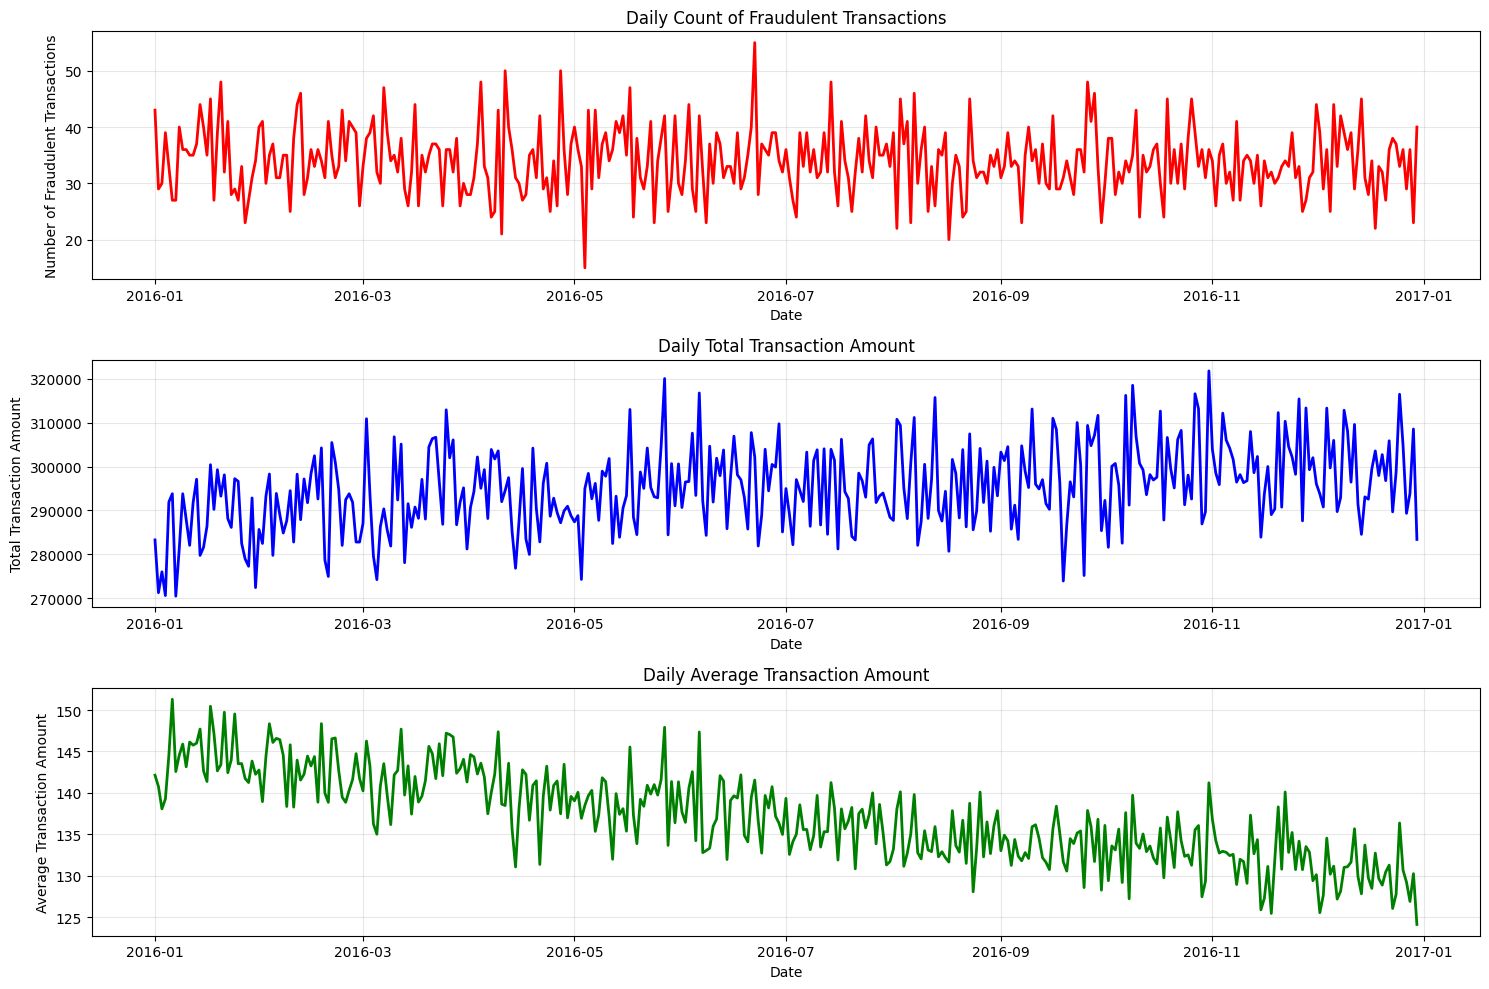

In [14]:
# Create time series analysis at daily level
# Track three metrics: fraud count, total transaction amount, and average transaction amount
df["transactionDate"] = pd.to_datetime(df["transactionDateTime"]).dt.date
daily_stats = df.groupby("transactionDate").agg(
    fraud_count = ("isFraud", "sum"),
    total_amount = ("transactionAmount", "sum"),
    mean_amount = ("transactionAmount", "mean")
).reset_index()

# Plot three time series
plt.figure(figsize=(15, 10))

# Subplot 1: Daily fraudulent transaction count
plt.subplot(3, 1, 1)
plt.plot(daily_stats["transactionDate"], daily_stats["fraud_count"], color="red", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Daily Count of Fraudulent Transactions")
plt.grid(True, alpha=0.3)

# Subplot 2: Daily total transaction volume
plt.subplot(3, 1, 2)
plt.plot(daily_stats["transactionDate"], daily_stats["total_amount"], color="blue", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Total Transaction Amount")
plt.title("Daily Total Transaction Amount")
plt.grid(True, alpha=0.3)

# Subplot 3: Daily average transaction amount
plt.subplot(3, 1, 3)
plt.plot(daily_stats["transactionDate"], daily_stats["mean_amount"], color="green", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Average Transaction Amount")    
plt.title("Daily Average Transaction Amount")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Analyze fraud probability and contribution by merchant category code
# Shows which merchant categories are most associated with fraud
df.groupby(['merchantCategoryCode']).agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob_cond = ("isFraud", lambda x: x.sum() / len(df.query("isFraud == True"))), # % of total fraud from this category
    fraud_amount_prop_cond = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / df.query("isFraud == True")["transactionAmount"].sum() if df.query("isFraud == True")["transactionAmount"].sum() > 0 else 0), # % of total fraud amount
    fraud_prob = ("isFraud", "mean"), # overall fraud rate for this category
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0) # % of category total that is fraud
).sort_values("fraud_prob_cond", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob_cond,fraud_amount_prop_cond,fraud_prob,fraud_amount_prop
merchantCategoryCode,,,,,,
online_retail,202156,4938,0.397681,0.424644,0.024427,0.040448
online_gifts,66238,1606,0.129339,0.141077,0.024246,0.040760
rideshare,51136,1272,0.102440,0.107544,0.024875,0.040222
fastfood,112138,1074,0.086494,0.069513,0.009577,0.011907
food,75490,1014,0.081662,0.076338,0.013432,0.019461
entertainment,80098,961,0.077394,0.062745,0.011998,0.015000
airline,15412,534,0.043006,0.039849,0.034648,0.049881
auto,21651,273,0.021986,0.021210,0.012609,0.018914
hotels,34097,250,0.020134,0.019369,0.007332,0.010912


## 5. Entity Risk Analysis (Merchants, Categories)

Identify high-risk merchants and transaction categories based on fraud patterns.

In [16]:
# Create summary statistics dataframe for merchant categories
entity_df = df.groupby(['merchantCategoryCode']).agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),  # fraud rate for this category
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0)
)

In [17]:
# Top merchant categories by transaction volume
entity_df.sort_values("total_transactions", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop
merchantCategoryCode,,,,
online_retail,202156,4938,0.024427,0.040448
fastfood,112138,1074,0.009577,0.011907
entertainment,80098,961,0.011998,0.015000
food,75490,1014,0.013432,0.019461
online_gifts,66238,1606,0.024246,0.040760
rideshare,51136,1272,0.024875,0.040222
hotels,34097,250,0.007332,0.010912
fuel,23910,0,0.000000,0.000000
subscriptions,22901,216,0.009432,0.014681


In [18]:
# Top merchant categories by absolute fraud transaction count
entity_df.sort_values("fraud_transactions", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop
merchantCategoryCode,,,,
online_retail,202156,4938,0.024427,0.040448
online_gifts,66238,1606,0.024246,0.040760
rideshare,51136,1272,0.024875,0.040222
fastfood,112138,1074,0.009577,0.011907
food,75490,1014,0.013432,0.019461
entertainment,80098,961,0.011998,0.015000
airline,15412,534,0.034648,0.049881
auto,21651,273,0.012609,0.018914
hotels,34097,250,0.007332,0.010912


In [19]:
# Analyze fraud correlation with CVV mismatch
# CVV mismatches or missing CVV codes are strong fraud indicators
# Create CVV match status categories: Missing, Mismatch, or Match
df['cvvMatchCode'] = np.where(
    df['enteredCVV'].isna() | df['cardCVV'].isna(), 
    "Missing", 
    np.where(df['enteredCVV'] != df['cardCVV'], "Mismatch", "Match")
)

# Analyze fraud probability by CVV match status
df.groupby("cvvMatchCode").agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0)
).sort_values("fraud_prob", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop
cvvMatchCode,,,,
Mismatch,7015,203,0.028938,0.048081
Match,779348,12214,0.015672,0.025763


## 6. Behavioral Indicators Analysis

Analyze key transaction characteristics that indicate fraud risk (CVV mismatches, card presence, account age, utilization, etc.).

In [20]:
# Analyze fraud correlation with card presence and transaction amount
# Cross-tabulation of fraud status with card presence indicator
print("Fraud Distribution by Card Presence:")
display(df.pivot_table(index="isFraud", columns="cardPresent", values="accountNumber", aggfunc="count"))

print("\nTransaction Amount Statistics by Fraud Status:")
display(df.pivot_table(index="isFraud", values="transactionAmount", aggfunc=["sum", "mean"]))

Fraud Distribution by Card Presence:


cardPresent,False,True
isFraud,,
False,424533,349413
True,8962,3455



Transaction Amount Statistics by Fraud Status:


,sum,mean
,transactionAmount,transactionAmount
isFraud,,
False,1.049241e+08,135.570249
True,2.796506e+06,225.215905


In [21]:
# Analyze fraud correlation with account age
# New accounts (less than 30 days old) tend to have higher fraud rates
df['accountAge'] = (pd.to_datetime(df['transactionDateTime']) - pd.to_datetime(df['accountOpenDate'])).dt.days
df['accountage_group'] = pd.cut(
    df['accountAge'], 
    bins=[-1, 30, 90, 180, 365, 730, 1095, np.inf], 
    labels=["0-30 days", "31-90 days", "91-180 days", "181-365 days", "1-2 years", "2-3 years", "3+ years"]
)

# Analyze fraud statistics by account age group
df.groupby("accountage_group").agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0),
    fraud_prob_cond = ("isFraud", lambda x: x.sum() / len(df.query("isFraud == True"))), # % of total fraud
    fraud_amount_prop_cond = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / df.query("isFraud == True")["transactionAmount"].sum() if df.query("isFraud == True")["transactionAmount"].sum() > 0 else 0) # % of total fraud amount
).sort_values("fraud_prob_cond", ascending=False).head(20)

/tmp/ipykernel_1997/1964804610.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("accountage_group").agg(


,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop,fraud_prob_cond,fraud_amount_prop_cond
accountage_group,,,,,,
1-2 years,282065,4648,0.016478,0.027130,0.374326,0.377519
2-3 years,158442,2752,0.017369,0.028044,0.221632,0.217524
3+ years,199754,2712,0.013577,0.022516,0.218410,0.216958
181-365 days,110605,1739,0.015723,0.026291,0.140050,0.142228
91-180 days,25714,422,0.016411,0.026597,0.033986,0.034685
31-90 days,8530,120,0.014068,0.020833,0.009664,0.009073
0-30 days,1253,24,0.019154,0.032126,0.001933,0.002013


In [22]:
# Analyze fraud correlation with credit card utilization
# Calculate utilization as (used credit / credit limit)
df['utilization'] = df['availableMoney'] / df['creditLimit']

# Compare utilization patterns between fraudulent and legitimate transactions
df.groupby("isFraud").agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    avg_utilization = ("utilization", "mean"),
    avg_utilization_fraud_only = ("utilization", lambda x: x[df.loc[x.index, "isFraud"] == True].mean() if len(x[df.loc[x.index, "isFraud"] == True]) > 0 else 0)
).sort_values("fraud_prob", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob,avg_utilization,avg_utilization_fraud_only
isFraud,,,,,
True,12417,12417,1.0,0.521902,0.521902
False,773946,0,0.0,0.539865,0.000000


In [23]:
# Preview the updated dataframe with new features
df.expirationDateKeyInMatch.unique()

array([False,  True])

In [24]:
# Analyze fraud correlation with cross-border transactions
# Cross-border transactions may indicate higher fraud risk
df['crossBorder'] = np.where(
    df['acqCountry'].isna() | df['merchantCountryCode'].isna(), 
    "Unknown", 
    np.where(df['acqCountry'] != df['merchantCountryCode'], "Cross-Border", "Domestic")
)

# Analyze fraud statistics by transaction type (domestic vs cross-border)
df.groupby("crossBorder").agg(
    total_transactions = ("accountNumber", "count"),    
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0)
).sort_values("fraud_prob", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop
crossBorder,,,,
Cross-Border,3911,67,0.017131,0.033777
Domestic,782452,12350,0.015784,0.025922


In [25]:
# Analyze fraud correlation with transaction type
# Different transaction types (e.g., online, in-person, ATM) may have different fraud rates
df.groupby("transactionType").agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0)
).sort_values("fraud_prob", ascending=False).head(20)

,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop
transactionType,,,,
,698,14,0.020057,0.038414
REVERSAL,20303,337,0.016599,0.027221
PURCHASE,745193,11950,0.016036,0.025914
ADDRESS_VERIFICATION,20169,116,0.005751,0.000000


In [26]:
## months remaining to expiry analysis
df['months_to_expiry'] = (pd.to_datetime(df['currentExpDate']) - pd.to_datetime(df['transactionDateTime'])).dt.days // 30
df['expiry_group'] = pd.cut(
    df['months_to_expiry'],
    bins=[-1, 0, 3, 6, 12, np.inf],
    labels=["Expired", "0-3 months", "3-6 months", "6-12 months", "12+ months"]
)
# Analyze fraud statistics by card expiry group
df.groupby("expiry_group").agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0),
    fraud_prob_cond = ("isFraud", lambda x: x.sum() / len(df.query("isFraud == True"))), # % of total fraud
    fraud_amount_prop_cond = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / df.query("isFraud == True")["transactionAmount"].sum() if df.query("isFraud == True")["transactionAmount"].sum() > 0 else 0) # % of total fraud amount
).sort_values("fraud_prob_cond", ascending=False).head(20)

/tmp/ipykernel_1997/2821536365.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['months_to_expiry'] = (pd.to_datetime(df['currentExpDate']) - pd.to_datetime(df['transactionDateTime'])).dt.days // 30
/tmp/ipykernel_1997/2821536365.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("expiry_group").agg(


,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop,fraud_prob_cond,fraud_amount_prop_cond
expiry_group,,,,,,
12+ months,786363,12417,0.01579,0.025961,1.0,1.0
Expired,0,0,NaN,0.000000,0.0,0.0
0-3 months,0,0,NaN,0.000000,0.0,0.0
3-6 months,0,0,NaN,0.000000,0.0,0.0
6-12 months,0,0,NaN,0.000000,0.0,0.0


In [27]:
##  expirationDateKeyInMatch analysis by comparing fraud rates for transactions where the expiration date key matches vs does not match
df['expiryKeyMatch'] = np.where(
    df['expirationDateKeyInMatch'] == True,
    "Match",
    np.where(df['expirationDateKeyInMatch'] == False, "Mismatch", "Unknown")
)

# Analyze fraud statistics by expiration date key match status
df.groupby("expiryKeyMatch").agg(
    total_transactions = ("accountNumber", "count"),
    fraud_transactions = ("isFraud", "sum"),
    fraud_prob = ("isFraud", "mean"),
    fraud_amount_prop = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / x.sum() if x.sum() > 0 else 0),
    fraud_prob_cond = ("isFraud", lambda x: x.sum() / len(df.query("isFraud == True"))), # % of total fraud
    fraud_amount_prop_cond = ("transactionAmount", lambda x: x[df.loc[x.index, "isFraud"] == True].sum() / df.query("isFraud == True")["transactionAmount"].sum() if df.query("isFraud == True")["transactionAmount"].sum() > 0 else 0) # % of total fraud amount
).sort_values("fraud_prob_cond", ascending=False).head(20)  

,total_transactions,fraud_transactions,fraud_prob,fraud_amount_prop,fraud_prob_cond,fraud_amount_prop_cond
expiryKeyMatch,,,,,,
Mismatch,785320,12404,0.015795,0.025981,0.998953,0.999368
Match,1043,13,0.012464,0.011762,0.001047,0.000632


In [28]:
# Calculate mutual information between each feature and the fraud label
# Mutual information measures how much knowing a feature reduces uncertainty about fraud
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Select features for importance analysis
feature_cols = ['accountNumber', 'customerId', 'creditLimit', 'availableMoney',
        'transactionAmount', 'merchantName',
       'acqCountry', 'merchantCountryCode', 'posEntryMode', 'posConditionCode',
       'merchantCategoryCode', 'accountOpenDate',
       'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits',
       'transactionType', 'echoBuffer', 'currentBalance', 'merchantCity',
       'merchantState', 'merchantZip', 'cardPresent', 'posOnPremises',
       'recurringAuthInd', 'expirationDateKeyInMatch',
       'cvvMatchCode', 'accountAge', 'accountage_group', 'utilization',
       'crossBorder']

# Prepare feature matrix and target label
X = df[feature_cols].copy()
y = df['isFraud']

# Encode all categorical/object columns to numeric values
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Fill any remaining missing values
X = X.fillna(0)

# Identify discrete features (categorical/integer columns)
discrete_mask = [X[col].dtype in ['int64', 'int32'] or col in 
                 df[feature_cols].select_dtypes(include=['object', 'category']).columns 
                 for col in X.columns]

# Calculate mutual information scores
mi_scores = mutual_info_classif(X, y, discrete_features=discrete_mask)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Display results
print("Mutual Information Scores of Features with Fraud Label:")
print("(Higher scores indicate more informative features for fraud prediction)")
print(mi_scores_series)

Mutual Information Scores of Features with Fraud Label:
(Higher scores indicate more informative features for fraud prediction)
cardPresent                 9.625306e-02
creditLimit                 2.045158e-02
accountNumber               9.530365e-03
customerId                  9.530365e-03
cardLast4Digits             9.179171e-03
accountOpenDate             6.104951e-03
merchantName                5.829562e-03
dateOfLastAddressChange     4.617703e-03
cardCVV                     4.248340e-03
enteredCVV                  4.169017e-03
transactionAmount           3.515781e-03
merchantCategoryCode        2.939499e-03
accountAge                  2.777516e-03
posEntryMode                1.832087e-03
utilization                 7.181915e-04
availableMoney              2.474448e-04
currentBalance              1.368289e-04
merchantCountryCode         1.281295e-04
posConditionCode            1.256576e-04
transactionType             1.126542e-04
accountage_group            6.511062e-05
acqCountry 

## 7. Feature Importance Analysis

Use mutual information to identify the most informative features for fraud detection.

##### ***Feature Generation / Feature Engineering / Feature Extraction***

In [29]:
# # Create velocity feature: number of transactions in the past 24 hours for the same account
# # High transaction velocity can indicate fraudulent activity (account takeover, card testing, etc.)
# # This feature can be generalized for different time windows (1h, 6h, 12h, 48h) or different entities

# # Sort by datetime to ensure proper rolling window calculation
# df = df.sort_values("transactionDateTime")
# df['transactionDateTime'] = pd.to_datetime(df['transactionDateTime'])

# # Calculate 24-hour transaction velocity per account
# # Rolling window counts transactions in past 24 hours, excluding current transaction
# df['transactionVelocity24h'] = df.groupby('accountNumber')['transactionDateTime'].transform(
#     lambda x: x.rolling('24h').count() - 1
# )

# print("Transaction Velocity Feature created successfully")
# print(f"Velocity statistics:\n{df['transactionVelocity24h'].describe()}")

In [30]:
## train-test split before modeling to prevent data leakage and ensure realistic evaluation of model performance on unseen data.
## last 2 months will be used as test set to evaluate model performance on recent data, while older data will be used for training.

from sklearn.model_selection import train_test_split

X = df.drop(['isFraud'], axis=1)
y = df['isFraud']

train_df, test_df = df[pd.to_datetime(df['transactionDateTime']) < (pd.to_datetime(df['transactionDateTime']).max() - pd.Timedelta(days=60))], df[pd.to_datetime(df['transactionDateTime']) >= (pd.to_datetime(df['transactionDateTime']).max() - pd.Timedelta(days=60))]

In [31]:
## velocity feature extraction for each account
# last 24h, 48h, 72h, 1 week, 2 weeks, 1 month, 3 months, 6 months, 1 year, etc.

import pandas as pd
import numpy as np

def build_history_features(
    df,
    entity_col,
    datetime_col,
    feature_type,
    windows=['1h', '24h', '48h', '72h', '7D', '14D', '30D', '90D', '180D', '365D']
):
    """
    Build rolling time-window history features per entity.

    Parameters
    ----------
    entity_col   : str   — column to group by (e.g. 'accountNumber')
    datetime_col : str   — datetime column (will be set as index for rolling)
    feature_type : str   — one of:
                           'velocity'    → count of transactions in window
                           'amount_sum'  → sum of transactionAmount in window
                           'amount_mean' → mean of transactionAmount in window
                           'amount_std'  → std  of transactionAmount in window
                           'amount_max'  → max  of transactionAmount in window
                           'total_fraud' → count of past frauds in window
                           'fraud_rate'  → fraction of past txns that were fraud
    windows      : list  — pandas offset strings
    """

    CONFIGS = {
        'velocity':    {'col': '_ones',             'agg': 'sum',  'fill': 0,   'dtype': int},
        'amount_sum':  {'col': 'transactionAmount', 'agg': 'sum',  'fill': 0.0, 'dtype': float},
        'amount_mean': {'col': 'transactionAmount', 'agg': 'mean', 'fill': 0.0, 'dtype': float},
        'amount_std':  {'col': 'transactionAmount', 'agg': 'std',  'fill': 0.0, 'dtype': float},
        'amount_max':  {'col': 'transactionAmount', 'agg': 'max',  'fill': 0.0, 'dtype': float},
        'total_fraud': {'col': 'isFraud',           'agg': 'sum',  'fill': 0,   'dtype': int},
        'fraud_rate':  {'col': 'isFraud',           'agg': 'mean', 'fill': 0.0, 'dtype': float},
    }

    if feature_type not in CONFIGS:
        raise ValueError(
            f"Unsupported feature_type '{feature_type}'. "
            f"Choose from: {list(CONFIGS.keys())}"
        )

    cfg = CONFIGS[feature_type]

    df = df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.sort_values([entity_col, datetime_col]).reset_index(drop=True)
    df['_ones'] = 1  # needed for velocity

    for window in windows:
        derived_col = f'{feature_type}_{entity_col}_{window}'

        df = df.set_index(datetime_col)

        rolled = (
            df.groupby(entity_col)[cfg['col']]
              .rolling(window, closed='left')
              .agg(cfg['agg'])
              .reset_index(level=0, drop=True)
              .fillna(cfg['fill'])
              .astype(cfg['dtype'])
        )

        df[derived_col] = rolled
        df = df.reset_index()

    df = df.drop(columns='_ones')
    return df

In [32]:
# velocity — how many txns in the window
df = build_history_features(df, 'accountNumber', 'transactionDateTime', 'velocity')

# spending sum and mean per account
df = build_history_features(df, 'accountNumber', 'transactionDateTime', 'amount_sum')
df = build_history_features(df, 'accountNumber', 'transactionDateTime', 'amount_mean')

# std dev of spend — high std = erratic spending = fraud signal
df = build_history_features(df, 'accountNumber', 'transactionDateTime', 'amount_std')

# past fraud count and rate — extremely powerful if labels exist in history
df = build_history_features(df, 'accountNumber', 'transactionDateTime', 'total_fraud')
df = build_history_features(df, 'accountNumber', 'transactionDateTime', 'fraud_rate')

# works on any entity — merchant-level features too
df = build_history_features(df, 'merchantName', 'transactionDateTime', 'fraud_rate',
                             windows=['7D', '30D', '90D'])

In [33]:
### days since last transaction feature
# captures recency of activity — long time since last txn can indicate dormant account or new fraud

def build_recency_feature(df, entity_col, datetime_col):
    """
    Build recency feature: days since last transaction for each entity.

    Parameters
    ----------
    df          : DataFrame — input data
    entity_col   : str       — column to group by (e.g. 'accountNumber')
    datetime_col : str       — datetime column (will be set as index)
    """
    df = df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.sort_values([entity_col, datetime_col]).reset_index(drop=True)

    # Calculate days since last transaction per entity
    df['days_since_last_txn'] = (
        df.groupby(entity_col)[datetime_col]
          .diff()
          .dt.total_seconds() // (24 * 3600)  # convert to days
    )

    # Fill missing values (first transaction for each entity) with a large number or median
    df['days_since_last_txn'] = df['days_since_last_txn'].fillna(df['days_since_last_txn'].median())
    
    return df

df = build_recency_feature(df, 'accountNumber', 'transactionDateTime')

In [34]:
## this time this day this week this month features
# captures seasonality patterns — fraudsters may target specific times (e.g. holidays, weekends, end of month)

def build_time_seasonality_features(df, datetime_col):
    """
    Build time-based seasonality features from a datetime column.

    Parameters
    ----------
    df          : DataFrame — input data
    datetime_col : str       — datetime column to extract features from
    """
    df = df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col])

    # Extract time-based features
    df['hour'] = df[datetime_col].dt.hour
    df['day_of_week'] = df[datetime_col].dt.dayofweek  # Monday=0, Sunday=6
    df['day_of_month'] = df[datetime_col].dt.day
    df['month'] = df[datetime_col].dt.month

    # Create binary features for specific time periods (e.g. weekend, end of month)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # Saturday and Sunday
    df['is_end_of_month'] = (df['day_of_month'] >= 25).astype(int)  # Last week of month
    df['is_late_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)  # Midnight to 6 AM

    return df

df = build_time_seasonality_features(df, 'transactionDateTime')

In [35]:
### location-based features
# captures geographic patterns — fraud may be more common in certain regions or when transactions occur far from typical locations

def build_location_features(df, country_col, city_col):
    """
    Build location-based features from country and city columns.

    Parameters
    ----------
    df          : DataFrame — input data
    country_col  : str       — column containing country information
    city_col     : str       — column containing city information
    """
    df = df.copy()

    # Create a combined location feature (e.g. "Country_City")
    df['location'] = df[country_col].fillna('Unknown') + '_' + df[city_col].fillna('Unknown')

    # Calculate frequency of transactions per location
    location_counts = df['location'].value_counts()
    df['location_txn_count'] = df['location'].map(location_counts)

    # Calculate fraud rate per location
    location_fraud_rate = df.groupby('location')['isFraud'].mean()
    df['location_fraud_rate'] = df['location'].map(location_fraud_rate)

    return df

df = build_location_features(df, 'acqCountry', 'merchantCity')

In [36]:
### cvv and expiry mismatch features
# captures card verification issues — mismatches in CVV or expiry date can indicate fraud

def build_cvv_expiry_mismatch_features(df):
    """
    Build CVV and expiry mismatch features.

    Parameters
    ----------
    df : DataFrame — input data containing 'enteredCVV', 'cardCVV', 'expirationDateKeyInMatch'
    """
    df = df.copy()

    # CVV mismatch feature
    df['cvv_mismatch'] = np.where(
        df['enteredCVV'].isna() | df['cardCVV'].isna(), 
        "Missing", 
        np.where(df['enteredCVV'] != df['cardCVV'], "Mismatch", "Match")
    )

    # Expiry date mismatch feature (already exists as 'expirationDateKeyInMatch')
    df['expiry_mismatch'] = np.where(
        df['expirationDateKeyInMatch'] == True,
        "Match",
        np.where(df['expirationDateKeyInMatch'] == False, "Mismatch", "Unknown")
    )

    return df

df = build_cvv_expiry_mismatch_features(df)

In [37]:
### account age and tenure features
# captures lifecycle patterns — new accounts may have different fraud risk than long-standing accounts

def build_account_age_features(df, account_open_date_col, transaction_date_col):
    """
    Build account age and tenure features.

    Parameters
    ----------
    df                    : DataFrame — input data containing account open date and transaction date
    account_open_date_col : str       — column name for account open date
    transaction_date_col  : str       — column name for transaction date
    """
    df = df.copy()
    df[account_open_date_col] = pd.to_datetime(df[account_open_date_col])
    df[transaction_date_col] = pd.to_datetime(df[transaction_date_col])

    # Calculate account age in days at the time of transaction
    df['account_age_days'] = (df[transaction_date_col] - df[account_open_date_col]).dt.days

    # Create age groups (e.g. 0-30 days, 31-90 days, etc.)
    df['account_age_group'] = pd.cut(
        df['account_age_days'], 
        bins=[-1, 30, 90, 180, 365, 730, 1095, np.inf], 
        labels=["0-30 days", "31-90 days", "91-180 days", "181-365 days", "1-2 years", "2-3 years", "3+ years"]
    )

    return df

df = build_account_age_features(df, 'accountOpenDate', 'transactionDateTime')

In [38]:
### utilization features
# captures credit usage patterns — high utilization can indicate financial distress or fraud

def build_utilization_features(df, available_money_col, credit_limit_col):
    """
    Build credit utilization features.

    Parameters
    ----------
    df                   : DataFrame — input data containing available money and credit limit
    available_money_col  : str       — column name for available money
    credit_limit_col     : str       — column name for credit limit
    """
    df = df.copy()

    # Calculate utilization as (used credit / credit limit)
    df['utilization'] = df[available_money_col] / df[credit_limit_col]

    # Handle cases where credit limit is zero to avoid division by zero
    df['utilization'] = df['utilization'].replace([np.inf, -np.inf], 0).fillna(0)

    return df

df = build_utilization_features(df, 'availableMoney', 'creditLimit')

In [39]:
### amount to limit ratio feature
# captures how large the transaction amount is relative to the credit limit — high ratio can indicate fraud

def build_amount_to_limit_ratio(df, transaction_amount_col, credit_limit_col):
    """
    Build amount to credit limit ratio feature.

    Parameters
    ----------
    df                    : DataFrame — input data containing transaction amount and credit limit
    transaction_amount_col : str       — column name for transaction amount
    credit_limit_col      : str       — column name for credit limit
    """
    df = df.copy()

    # Calculate amount to limit ratio
    df['amount_to_limit_ratio'] = df[transaction_amount_col] / df[credit_limit_col]

    # Handle cases where credit limit is zero to avoid division by zero
    df['amount_to_limit_ratio'] = df['amount_to_limit_ratio'].replace([np.inf, -np.inf], 0).fillna(0)

    return df

df = build_amount_to_limit_ratio(df, 'transactionAmount', 'creditLimit')

In [40]:
### is cross-border feature
# captures international transaction patterns — cross-border transactions may have higher fraud risk

def build_cross_border_feature(df, acq_country_col, merchant_country_col):
    """
    Build cross-border transaction feature.

    Parameters
    ----------
    df                 : DataFrame — input data containing acquiring country and merchant country
    acq_country_col    : str       — column name for acquiring country
    merchant_country_col : str     — column name for merchant country
    """
    df = df.copy()

    # Create cross-border feature based on country comparison
    df['crossBorder'] = np.where(
        df[acq_country_col].isna() | df[merchant_country_col].isna(), 
        "Unknown", 
        np.where(df[acq_country_col] != df[merchant_country_col], "Cross-Border", "Domestic")
    )

    return df

df = build_cross_border_feature(df, 'acqCountry', 'merchantCountryCode')

In [41]:
## target encoding for entity features like merchantName, merchantCategoryCode, etc.
# captures entity-specific fraud patterns — some merchants or categories may have higher fraud rates

def build_target_encoding(df, entity_col, target_col):
    """
    Build target encoding for a categorical entity feature.

    Parameters
    ----------
    df         : DataFrame — input data containing the entity and target columns
    entity_col  : str       — column name for the categorical entity (e.g. 'merchantName')
    target_col  : str       — column name for the target variable (e.g. 'isFraud')
    """
    df = df.copy()

    # Calculate mean target value (fraud rate) for each category
    target_mean = df.groupby(entity_col)[target_col].mean()

    # Map the mean target value back to the original dataframe
    df[f'{entity_col}_target_enc'] = df[entity_col].map(target_mean)

    return df

# Apply target encoding to merchantName and merchantCategoryCode
df = build_target_encoding(df, 'merchantName', 'isFraud')
df = build_target_encoding(df, 'merchantCategoryCode', 'isFraud')

In [42]:
### days since the address change feature
# captures changes in customer information — recent address changes can be a fraud indicator

def build_days_since_address_change(df, address_change_date_col, transaction_date_col):
    """
    Build days since last address change feature.

    Parameters
    ----------
    df                      : DataFrame — input data containing address change date and transaction date
    address_change_date_col : str       — column name for date of last address change
    transaction_date_col    : str       — column name for transaction date
    """
    df = df.copy()
    df[address_change_date_col] = pd.to_datetime(df[address_change_date_col])
    df[transaction_date_col] = pd.to_datetime(df[transaction_date_col])

    # Calculate days since last address change at the time of transaction
    df['days_since_address_change'] = (df[transaction_date_col] - df[address_change_date_col]).dt.days

    # Fill missing values (no address change) with a large number or median
    df['days_since_address_change'] = df['days_since_address_change'].fillna(df['days_since_address_change'].median())
    
    return df

df = build_days_since_address_change(df, 'dateOfLastAddressChange', 'transactionDateTime')

In [43]:
### is a new merchant feature
# captures whether the transaction is with a new merchant for the account — new merchant interactions can indicate fraud

def build_is_new_merchant_feature(df, account_col, merchant_col, datetime_col):
    """
    Build is new merchant feature indicating if the transaction is with a new merchant for the account.

    Parameters
    ----------
    df          : DataFrame — input data containing account, merchant, and datetime columns
    account_col  : str       — column name for account identifier (e.g. 'accountNumber')
    merchant_col : str       — column name for merchant identifier (e.g. 'merchantName')
    datetime_col : str       — column name for transaction datetime
    """
    df = df.copy()
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.sort_values([account_col, datetime_col]).reset_index(drop=True)

    # Create a flag for whether the merchant has been seen before for the account
    df['is_new_merchant'] = ~df.duplicated(subset=[account_col, merchant_col], keep='first').astype(int)

    return df

df = build_is_new_merchant_feature(df, 'accountNumber', 'merchantName', 'transactionDateTime')

In [44]:
### pos risk tier feature
# captures risk associated with point-of-sale entry mode and condition — certain POS scenarios may have higher fraud risk

def build_pos_risk_tier_feature(df, pos_entry_mode_col, pos_condition_code_col):
    """
    Build POS risk tier feature based on entry mode and condition code.

    Parameters
    ----------
    df                      : DataFrame — input data containing POS entry mode and condition code
    pos_entry_mode_col      : str       — column name for POS entry mode
    pos_condition_code_col  : str       — column name for POS condition code
    """
    df = df.copy()

    # Define risk tiers based on combinations of entry mode and condition code
    def assign_pos_risk_tier(row):
        if row[pos_entry_mode_col] in ['01', '02'] and row[pos_condition_code_col] in ['00', '01']:
            return 'Low Risk'  # e.g. chip card present
        elif row[pos_entry_mode_col] in ['05', '06'] and row[pos_condition_code_col] in ['02', '03']:
            return 'Medium Risk'  # e.g. card not present, online
        else:
            return 'High Risk'  # e.g. manual entry, phone order

    df['pos_risk_tier'] = df.apply(assign_pos_risk_tier, axis=1)

    return df

df = build_pos_risk_tier_feature(df, 'posEntryMode', 'posConditionCode')

In [45]:
df.head()

,transactionDateTime,accountNumber,customerId,creditLimit,availableMoney,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,merchantCategoryCode,currentExpDate,accountOpenDate,dateOfLastAddressChange,...,is_end_of_month,is_late_night,location,location_txn_count,location_fraud_rate,cvv_mismatch,expiry_mismatch,account_age_days,account_age_group,amount_to_limit_ratio,merchantName_target_enc,merchantCategoryCode_target_enc,days_since_address_change,is_new_merchant,pos_risk_tier
0,2016-01-12 00:59:52,100088067,100088067,50000.0,50000.00,205.13,EZ Putt Putt #982199,US,US,02,01,entertainment,04/2028,2014-01-09,2014-01-09,...,0,1,US_,774709,0.015647,Match,Mismatch,733,2-3 years,0.004103,0.011224,0.011998,733,-1,Low Risk
1,2016-01-12 19:49:41,100088067,100088067,50000.0,49794.87,46.43,Dinosaur Sandwitch Bar #303701,US,US,05,01,food,02/2024,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,733,2-3 years,0.000929,0.008568,0.013432,733,-1,High Risk
2,2016-01-17 15:41:46,100088067,100088067,50000.0,49748.44,378.67,Mobile eCards,US,US,05,01,online_gifts,11/2031,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,738,2-3 years,0.007573,0.013981,0.024246,738,-1,High Risk
3,2016-02-02 19:57:18,100088067,100088067,50000.0,50000.00,66.07,EZ Putt Putt #40513,US,US,02,01,entertainment,12/2027,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,754,2-3 years,0.001321,0.017776,0.011998,754,-1,Low Risk
4,2016-02-03 04:48:54,100088067,100088067,50000.0,49933.93,141.60,34th BBQ #412895,US,US,09,08,food,11/2030,2014-01-09,2014-01-09,...,0,1,US_,774709,0.015647,Match,Mismatch,755,2-3 years,0.002832,0.010695,0.013432,755,-1,High Risk


## 8. Model Building & Training

Build and train machine learning models for fraud detection. This section includes:
- Data preparation (train/test split, encoding, scaling)
- Model selection (Logistic Regression, Random Forest, Gradient Boosting, etc.)
- Model training and cross-validation
- Hyperparameter tuning
- Performance evaluation (ROC, AUC, Precision, Recall, F1)

In [46]:
from sklearn.model_selection import train_test_split

X = df.drop(['isFraud'], axis=1)
y = df['isFraud']

train_df, test_df = df[pd.to_datetime(df['transactionDateTime']) < (pd.to_datetime(df['transactionDateTime']).max() - pd.Timedelta(days=60))], df[pd.to_datetime(df['transactionDateTime']) >= (pd.to_datetime(df['transactionDateTime']).max() - pd.Timedelta(days=60))]

In [47]:
# for i in df.columns:
#     print(i)


exclude_features = ['transactionDateTime', 'accountNumber', 'customerId', 'currentExpDate', 'accountOpenDate', 'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits']

In [60]:
### handle class imbalance
# scale_pos_weight from xgboost
# SMOTE + Tomek
# Threshold tuning to optimize for business metrics (e.g. maximize F1, minimize false positives, etc.) rather than just accuracy


from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

feature_cols = [col for col in df.columns if col != 'isFraud' and col not in exclude_features]

X_train = train_df[feature_cols].copy()
y_train = train_df['isFraud']
X_test  = test_df[feature_cols].copy()
y_test  = test_df['isFraud']

# ── Fill NaNs dtype-aware ─────────────────────────────────────────────────────
def fill_nulls(df):
    for col in df.columns:
        if df[col].dtype.name == 'category':
            # Add 'missing' as a valid category, then fill
            df[col] = df[col].cat.add_categories('missing').fillna('missing')
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna('missing')
        else:
            df[col] = df[col].fillna(0)
    return df

X_train = fill_nulls(X_train)
X_test  = fill_nulls(X_test)

# ── LabelEncode object + category columns ─────────────────────────────────────
for col in X_train.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = X_test[col].astype(str).map(
        lambda v, le=le: le.transform([v])[0] if v in le.classes_ else -1
    )

# ── Model ─────────────────────────────────────────────────────────────────────
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    scale_pos_weight=scale_pw,
    eval_metric='logloss',
)
model.fit(X_train, y_train)

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.75      0.86    135083
        True       0.04      0.77      0.08      1990

    accuracy                           0.75    137073
   macro avg       0.52      0.76      0.47    137073
weighted avg       0.98      0.75      0.85    137073

Confusion Matrix:
[[101656  33427]
 [   457   1533]]
ROC-AUC: 0.8441210423504


In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    classification_report, precision_score, recall_score,
    f1_score, make_scorer, roc_auc_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import TimeSeriesSplit, cross_validate
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── 1. feature selection ──────────────────────────────────────────────────────
feature_cols = [
    col for col in df.columns
    if col != 'isFraud' and col not in exclude_features
]

X_train = train_df[feature_cols].copy()
y_train = train_df['isFraud']
X_test  = test_df[feature_cols].copy()
y_test  = test_df['isFraud']

# ── 2. fill NaNs dtype-aware ──────────────────────────────────────────────────
def fill_nulls(df):
    for col in df.columns:
        if df[col].dtype.name == 'category':
            df[col] = df[col].cat.add_categories('missing').fillna('missing')
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna('missing')
        else:
            df[col] = df[col].fillna(0)
    return df

X_train = fill_nulls(X_train)
X_test  = fill_nulls(X_test)

# ── 3. label-encode object + category columns ─────────────────────────────────
label_encoders = {}
for col in X_train.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = X_test[col].astype(str).map(
        lambda v, le=le: le.transform([v])[0] if v in le.classes_ else -1
    )
    label_encoders[col] = le

# ── 4. class imbalance stats ──────────────────────────────────────────────────
n_legit  = (y_train == 0).sum()
n_fraud  = (y_train == 1).sum()
scale_pw = n_legit / n_fraud
k        = min(5, n_fraud - 1)   # guard for small fraud counts in early CV folds

print(f"Train  — legit: {n_legit:,}  fraud: {n_fraud:,}  ratio: {scale_pw:.1f}x")
print(f"Fraud rate     : {y_train.mean():.3%}")
print(f"SMOTE k        : {k}")

# ── 5. SMOTETomek ────────────────────────────────────────────────────────────
smote_tomek = SMOTETomek(
    smote=SMOTE(k_neighbors=k, random_state=42),
    tomek=TomekLinks(sampling_strategy='majority'),
    random_state=42
)

# ── 6. CV model — fixed rounds, NO early stopping ────────────────────────────
# early_stopping_rounds requires eval_set which cannot be safely passed
# through cross_validate across sklearn/xgboost/imblearn versions.
# Use fixed n_estimators=400 for CV; early stopping only in the final refit.
model_cv = xgb.XGBClassifier(
    scale_pos_weight = scale_pw,
    n_estimators     = 400,        # fixed — no early stopping in CV
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    eval_metric      = 'aucpr',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

pipe_cv = ImbPipeline(steps=[
    ('smote', smote_tomek),
    ('clf',   model_cv)
])

# ── 7. cross-validation ───────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

scorers = {
    'pr_auc'   : make_scorer(average_precision_score, needs_proba=True),
    'precision': make_scorer(precision_score,  zero_division=0),
    'recall'   : make_scorer(recall_score,     zero_division=0),
    'f1'       : make_scorer(f1_score,         zero_division=0),
}

print("\nRunning 5-fold TimeSeriesSplit CV with SMOTETomek inside each fold ...")
cv_results = cross_validate(
    pipe_cv,
    X_train.values, y_train.values,
    cv=tscv,
    scoring=scorers,
    return_train_score=True,
    n_jobs=1    # must be 1 — XGBoost parallelises internally per fold
)

# ── 8. CV results ─────────────────────────────────────────────────────────────
print(f"\n{'Metric':<14} {'Train':>8} {'Val':>8} {'Std':>8}  Status")
print("─" * 52)
for m in ['pr_auc', 'precision', 'recall', 'f1']:
    tr   = cv_results[f'train_{m}'].mean()
    va   = cv_results[f'test_{m}'].mean()
    sd   = cv_results[f'test_{m}'].std()
    flag = '⚠ overfit' if (tr - va) > 0.15 else '✓'
    print(f"{m:<14} {tr:>8.4f} {va:>8.4f} {sd:>8.4f}  {flag}")

# ── 9. final model — separate instance with early stopping ────────────────────
# CV told us the approach generalises.
# Now refit on full training data with early stopping to find exact best rounds.
model_final = xgb.XGBClassifier(
    scale_pos_weight      = scale_pw,
    n_estimators          = 1000,   # high ceiling — early stopping will cut it
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 40,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0
)

pipe_final = ImbPipeline(steps=[
    ('smote', smote_tomek),
    ('clf',   model_final)
])

print("\nRefitting final model on full training data ...")
pipe_final.fit(
    X_train.values, y_train.values,
    clf__eval_set=[(X_test.values, y_test.values)],
    clf__verbose=50
)

print(f"Best iteration : {model_final.best_iteration}")

# ── 10. evaluation ────────────────────────────────────────────────────────────
y_prob  = pipe_final.predict_proba(X_test.values)[:, 1]
pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nPR-AUC  : {pr_auc:.4f}  ← primary metric")
print(f"ROC-AUC : {roc_auc:.4f}  ← secondary")

# ── 11. optimal threshold via F2 ──────────────────────────────────────────────
precision_c, recall_c, thresholds_c = precision_recall_curve(y_test, y_prob)
f2_scores   = (5 * precision_c * recall_c) / (4 * precision_c + recall_c + 1e-9)
best_idx    = np.argmax(f2_scores)
best_thresh = thresholds_c[best_idx]

print(f"\nOptimal threshold : {best_thresh:.3f}")
print(f"Precision         : {precision_c[best_idx]:.3f}")
print(f"Recall            : {recall_c[best_idx]:.3f}")
print(f"F2                : {f2_scores[best_idx]:.3f}")

y_pred = (y_prob >= best_thresh).astype(int)
print("\n", classification_report(y_test, y_pred, target_names=['legit', 'fraud']))

# ── 12. resampling sanity check ───────────────────────────────────────────────
X_res, y_res = smote_tomek.fit_resample(X_train.values, y_train.values)
print(f"\nResampling effect on full train set:")
print(f"  Before : {len(y_train):,} samples  |  fraud rate {y_train.mean():.3%}")
print(f"  After  : {len(y_res):,} samples  |  fraud rate {y_res.mean():.3%}")

Train  — legit: 638,863  fraud: 10,427  ratio: 61.3x
Fraud rate     : 1.606%
SMOTE k        : 5

Running 5-fold TimeSeriesSplit CV with SMOTETomek inside each fold ...

Metric            Train      Val      Std  Status
────────────────────────────────────────────────────
pr_auc              nan      nan      nan  ✓
precision        0.0879   0.0481   0.0036  ✓
recall           0.9428   0.5545   0.1233  ⚠ overfit
f1               0.1593   0.0878   0.0038  ✓

Refitting final model on full training data ...
[0]	validation_0-aucpr:0.02396
[50]	validation_0-aucpr:0.07507
[100]	validation_0-aucpr:0.11020
[150]	validation_0-aucpr:0.13655
[200]	validation_0-aucpr:0.15659
[250]	validation_0-aucpr:0.16737
[300]	validation_0-aucpr:0.17891
[350]	validation_0-aucpr:0.19183
[400]	validation_0-aucpr:0.19887
[450]	validation_0-aucpr:0.20411
[500]	validation_0-aucpr:0.20643
[550]	validation_0-aucpr:0.21029
[600]	validation_0-aucpr:0.21195
[650]	validation_0-aucpr:0.21353
[700]	validation_0-aucpr:0.21391

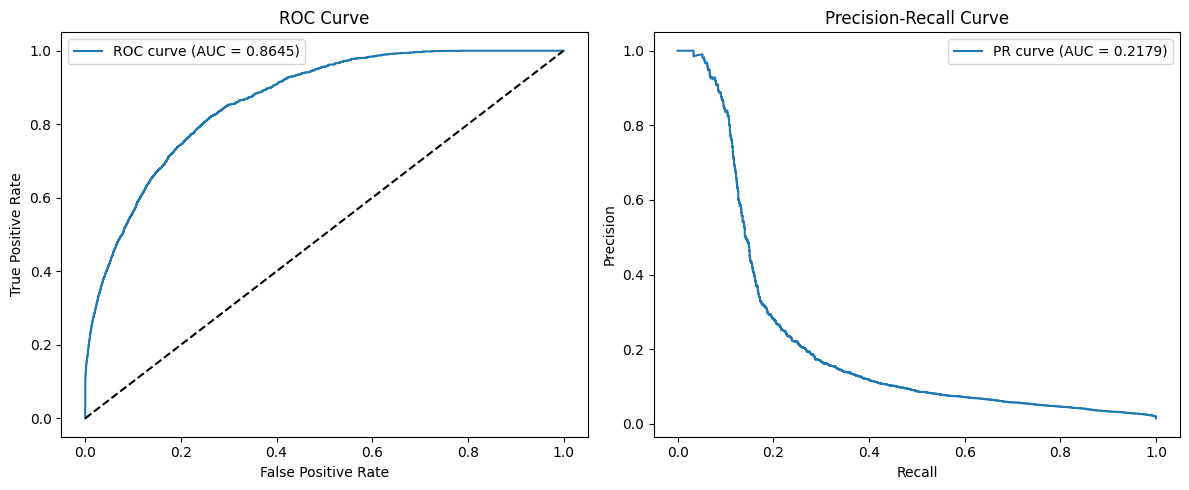

In [49]:
### AUC-ROC and AUC-PR curves
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend() 

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
### isolation forest for anomaly detection
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.02, random_state=42)
iso_forest.fit(X_train)
iso_preds = iso_forest.predict(X_test)
iso_preds = np.where(iso_preds == -1, 1, 0)
print("\nIsolation Forest Classification Report:")
print(classification_report(y_test, iso_preds, target_names=['legit', 'fraud']))


Isolation Forest Classification Report:
              precision    recall  f1-score   support

       legit       0.99      0.96      0.98    135083
       fraud       0.03      0.07      0.04      1990

    accuracy                           0.95    137073
   macro avg       0.51      0.52      0.51    137073
weighted avg       0.97      0.95      0.96    137073



In [64]:
X_train.head()

,transactionDateTime,accountNumber,customerId,creditLimit,availableMoney,transactionAmount,merchantName,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,merchantCategoryCode,currentExpDate,accountOpenDate,dateOfLastAddressChange,...,is_weekend,is_end_of_month,location,location_txn_count,location_fraud_rate,cvv_mismatch,expiry_mismatch,account_age_days,account_age_group,merchantName_target_enc,merchantCategoryCode_target_enc,amount_to_limit_ratio,days_since_address_change,is_new_merchant,pos_risk_tier
0,2016-01-12 00:59:52,100088067,100088067,50000.0,50000.00,205.13,EZ Putt Putt #982199,US,US,02,01,entertainment,04/2028,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,733,2-3 years,0.011224,0.011998,0.004103,733,-1,Low Risk
1,2016-01-12 19:49:41,100088067,100088067,50000.0,49794.87,46.43,Dinosaur Sandwitch Bar #303701,US,US,05,01,food,02/2024,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,733,2-3 years,0.008568,0.013432,0.000929,733,-1,High Risk
2,2016-01-17 15:41:46,100088067,100088067,50000.0,49748.44,378.67,Mobile eCards,US,US,05,01,online_gifts,11/2031,2014-01-09,2014-01-09,...,1,0,US_,774709,0.015647,Match,Mismatch,738,2-3 years,0.013981,0.024246,0.007573,738,-1,High Risk
3,2016-02-02 19:57:18,100088067,100088067,50000.0,50000.00,66.07,EZ Putt Putt #40513,US,US,02,01,entertainment,12/2027,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,754,2-3 years,0.017776,0.011998,0.001321,754,-1,Low Risk
4,2016-02-03 04:48:54,100088067,100088067,50000.0,49933.93,141.60,34th BBQ #412895,US,US,09,08,food,11/2030,2014-01-09,2014-01-09,...,0,0,US_,774709,0.015647,Match,Mismatch,755,2-3 years,0.010695,0.013432,0.002832,755,-1,High Risk


## Key Findings & Next Steps

### Insights from EDA:
1. **Temporal Patterns**: Fraud rates vary by hour of day, day of week, and seasonally
2. **Merchant Risk**: Certain merchant categories show higher fraud rates
3. **Account Age**: New accounts (0-30 days) are at higher fraud risk
4. **CVV Mismatches**: Strong indicator of fraudulent transactions
5. **Cross-Border**: International transactions have different fraud patterns
6. **Transaction Velocity**: High velocity transactions may indicate suspicious activity

### Recommended Models:
- **Random Forest**: Handles non-linearity and feature interactions well
- **Gradient Boosting (XGBoost/LightGBM)**: Often achieves best performance, handles imbalanced data
- **Logistic Regression**: Baseline model, good interpretability
- **Neural Networks**: Deep learning approach for complex patterns

### Next Steps:
1. Implement data preprocessing and feature scaling
2. Handle class imbalance (oversampling, undersampling, or SMOTE)
3. Train multiple models and compare performance
4. Perform hyperparameter tuning on best performing model
5. Evaluate on test set using appropriate metrics (precision, recall, F1, AUC-ROC)
6. Create model deployment pipeline